AAI-2505M Rakhmetulina Assylzhan

In [ ]:
from datasets import load_dataset

dataset = load_dataset("dwb2023/brain-tumor-image-dataset-semantic-segmentation")

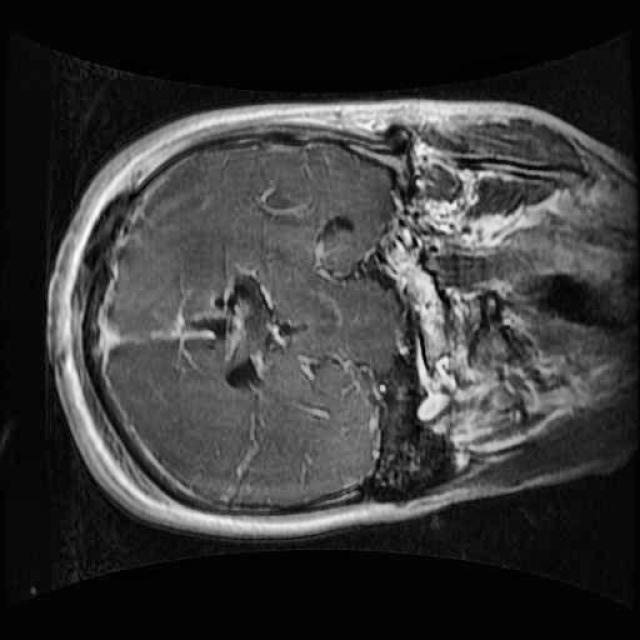

In [2]:
image = dataset["train"][0]["image"]
image

In [3]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import cv2

In [5]:
train_data = dataset["train"]
val_data = dataset["valid"]
test_data = dataset["test"]

In [6]:
for split in dataset:
    print(split, len(dataset[split]))

train 1502
test 215
valid 429


In [13]:
print(train_data[0].keys())

dict_keys(['file_name', 'image', 'id', 'category_id', 'bbox', 'segmentation', 'area', 'iscrowd', 'height', 'width', 'date_captured', 'license'])


In [81]:
IMG_SIZE = 128

def apply_clahe(img):
    img = img.astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(img)

def preprocess_image(img):
    img = np.array(img.convert("L"))
    img = apply_clahe(img)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img.astype(np.float32)

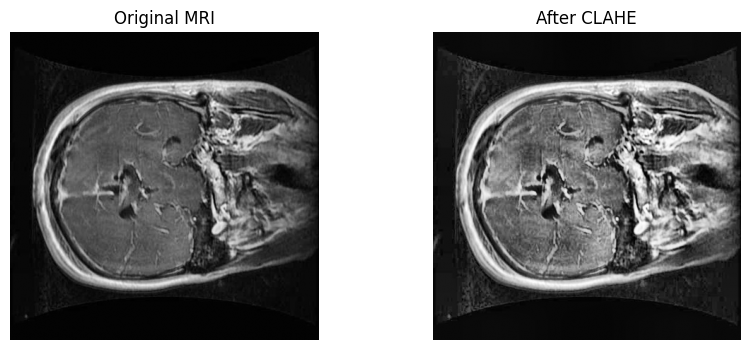

In [82]:
img = np.array(train_data[0]["image"].convert("L"))

clahe_img = apply_clahe(img)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Original MRI")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("After CLAHE")
plt.imshow(clahe_img, cmap="gray")
plt.axis("off")

plt.show()

In [83]:
def segmentation_to_mask(segmentation, h, w):
    mask = np.zeros((h, w), dtype=np.uint8)

    for poly in segmentation:
        pts = np.array(poly).reshape(-1, 2).astype(np.int32)
        cv2.fillPoly(mask, [pts], 1)

    return mask

In [84]:
class BrainTumorDataset(Dataset):
    def __init__(self, hf_dataset, augment=False):
        self.ds = hf_dataset
        self.augment = augment

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        s = self.ds[idx]

        # --- IMAGE ---
        image = preprocess_image(s["image"])

        # --- MASK ---
        mask = segmentation_to_mask(
            s["segmentation"],
            s["height"],
            s["width"]
        )

        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        # --- DATA AUGMENTATION (SAFE) ---
        if self.augment:
            if np.random.rand() > 0.5:
                image = np.fliplr(image).copy()
                mask  = np.fliplr(mask).copy()

            if np.random.rand() > 0.5:
                image = np.flipud(image).copy()
                mask  = np.flipud(mask).copy()

        image = torch.tensor(image).unsqueeze(0).float()
        mask  = torch.tensor(mask).unsqueeze(0).float()

        return image, mask


In [85]:
train_ds = BrainTumorDataset(train_data, augment=True)
val_ds   = BrainTumorDataset(val_data)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=8)

In [86]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)

In [87]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(1, 32)
        self.enc2 = DoubleConv(32, 64)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(64, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))

        b = self.bottleneck(self.pool(e2))

        d2 = self.dec2(torch.cat([self.up2(b), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.out(d1)

In [90]:
def dice_loss(pred, target):
    pred = torch.sigmoid(pred)
    smooth = 1e-5
    inter = (pred * target).sum()
    union = pred.sum() + target.sum()
    return 1 - (2 * inter + smooth) / (union + smooth)

def combined_loss(pred, target):
    return nn.BCEWithLogitsLoss()(pred, target) + dice_loss(pred, target)

In [89]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [91]:
for epoch in range(10):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        preds = model(x)
        loss = combined_loss(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: loss = {total_loss/len(train_loader):.4f}")

Epoch 1: loss = 1.0379
Epoch 2: loss = 0.7343
Epoch 3: loss = 0.6544
Epoch 4: loss = 0.6035
Epoch 5: loss = 0.5746
Epoch 6: loss = 0.5543
Epoch 7: loss = 0.5408
Epoch 8: loss = 0.5297
Epoch 9: loss = 0.5034
Epoch 10: loss = 0.4953


In [99]:
import matplotlib.pyplot as plt
import torch

def visualize_segmentation(model, dataset, idx, device, thr=0.5):
    model.eval()

    image, mask = dataset[idx]

    image = image.to(device)

    with torch.no_grad():
        pred = model(image.unsqueeze(0))
        pred = torch.sigmoid(pred)[0, 0].cpu().numpy()

    image = image[0].cpu().numpy()
    mask  = mask[0].cpu().numpy()

    fig, axs = plt.subplots(1, 4, figsize=(18, 4))

    axs[0].imshow(image, cmap="gray")
    axs[0].set_title("Input MRI")
    axs[0].axis("off")

    axs[1].imshow(mask, cmap="gray")
    axs[1].set_title("Ground Truth Segmentation")
    axs[1].axis("off")

    axs[2].imshow(pred, cmap="hot")
    axs[2].set_title("Predicted Probability Map")
    axs[2].axis("off")

    axs[3].imshow(image, cmap="gray")
    axs[3].imshow(pred > thr, alpha=0.5, cmap="Reds")
    axs[3].set_title("Overlay (Prediction)")
    axs[3].axis("off")

    plt.tight_layout()
    plt.show()

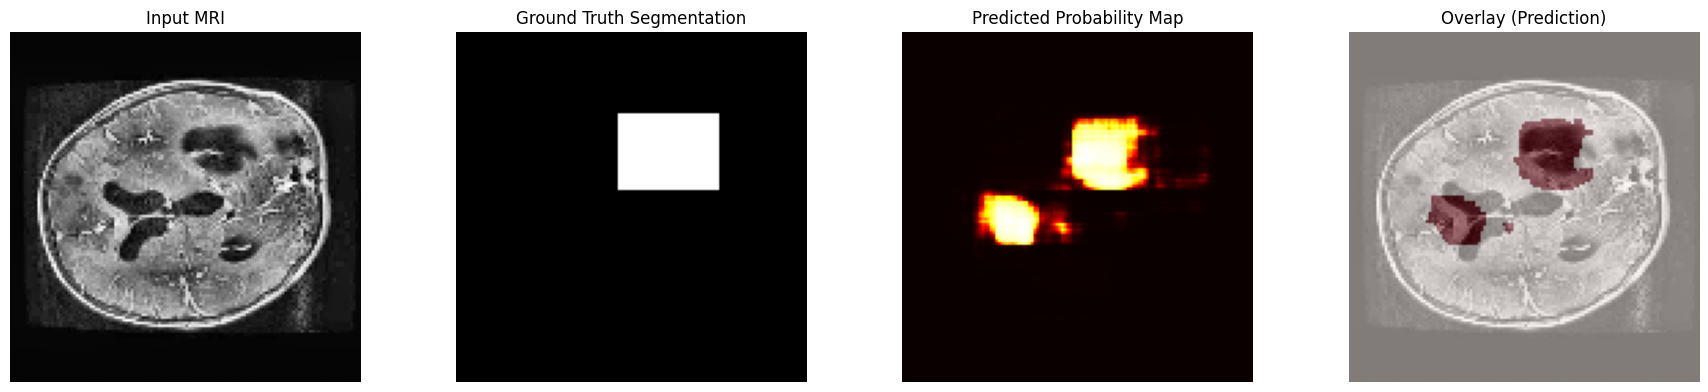

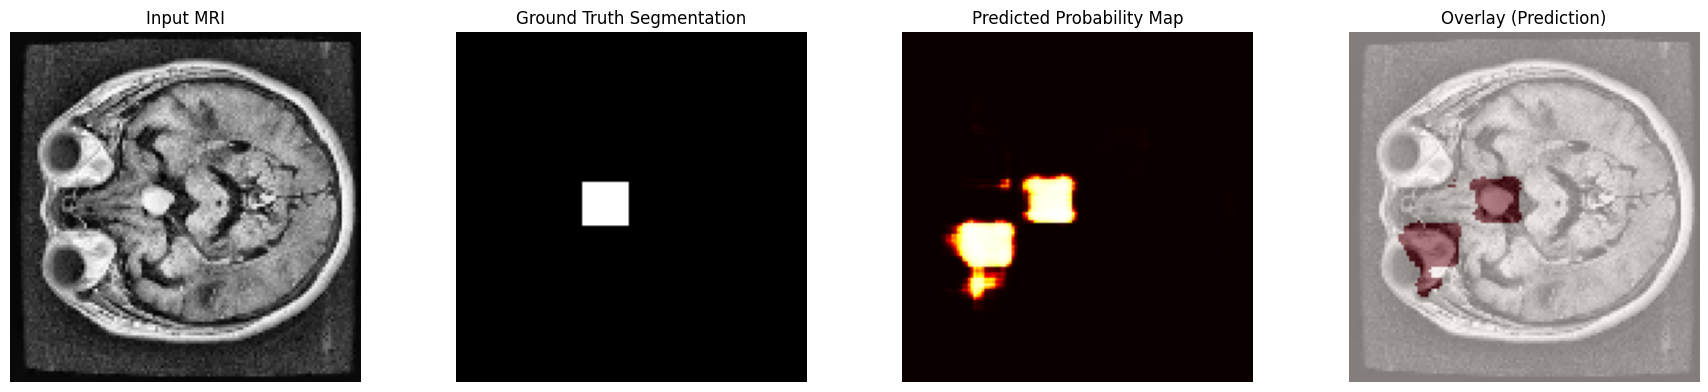

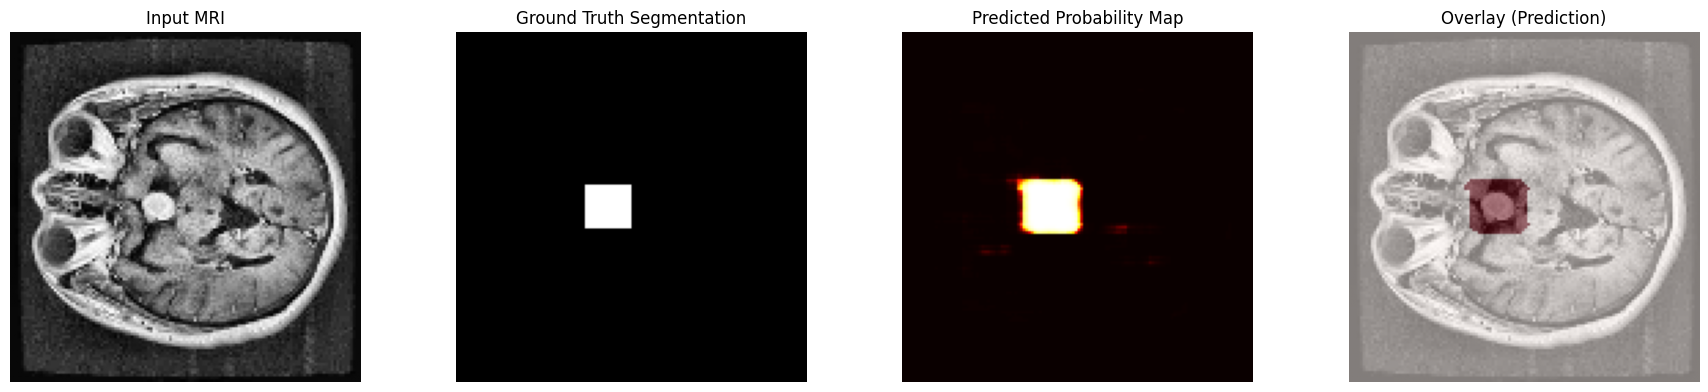

In [101]:
visualize_segmentation(model, train_ds, idx=5, device=device)
visualize_segmentation(model, train_ds, idx=40, device=device)
visualize_segmentation(model, val_ds,   idx=10, device=device)

In [103]:
test_ds = BrainTumorDataset(test_data)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False)

In [107]:
def dice_coeff(pred, target, thr=0.5):
    pred = (pred > thr).float()
    target = target.float()

    inter = (pred * target).sum()
    union = pred.sum() + target.sum()

    return (2 * inter + 1e-8) / (union + 1e-8)

In [104]:
def iou_score(pred, target, thr=0.5):
    pred = (pred > thr).float()
    target = target.float()

    inter = (pred * target).sum()
    union = pred.sum() + target.sum() - inter

    return (inter + 1e-8) / (union + 1e-8)

In [105]:
def pixel_accuracy(pred, target, thr=0.5):
    pred = (pred > thr).float()
    correct = (pred == target).float().sum()
    total = torch.numel(pred)
    return correct / total

In [106]:
def evaluate_model(model, loader, device):
    model.eval()

    dice_scores = []
    iou_scores = []
    acc_scores = []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            preds = torch.sigmoid(model(x))

            for i in range(x.size(0)):
                dice_scores.append(dice_coeff(preds[i], y[i]).item())
                iou_scores.append(iou_score(preds[i], y[i]).item())
                acc_scores.append(pixel_accuracy(preds[i], y[i]).item())

    return (
        np.mean(dice_scores),
        np.mean(iou_scores),
        np.mean(acc_scores)
    )

In [108]:
dice, iou, acc = evaluate_model(model, test_loader, device)

print(f"TEST Dice: {dice:.4f}")
print(f"TEST IoU: {iou:.4f}")
print(f"TEST Pixel Accuracy: {acc:.4f}")

TEST Dice: 0.5424
TEST IoU: 0.4261
TEST Pixel Accuracy: 0.9721


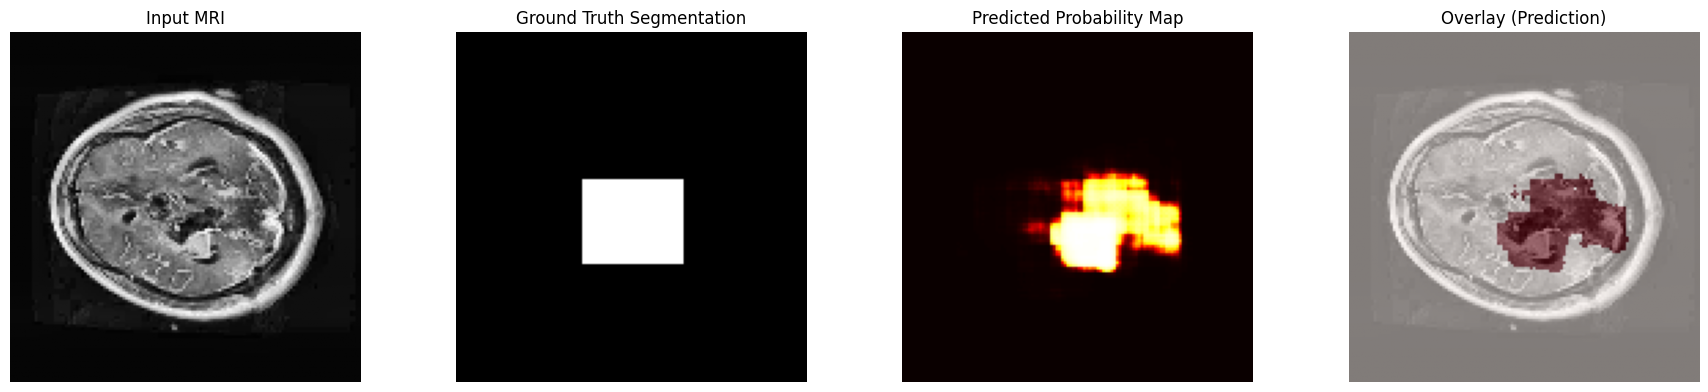

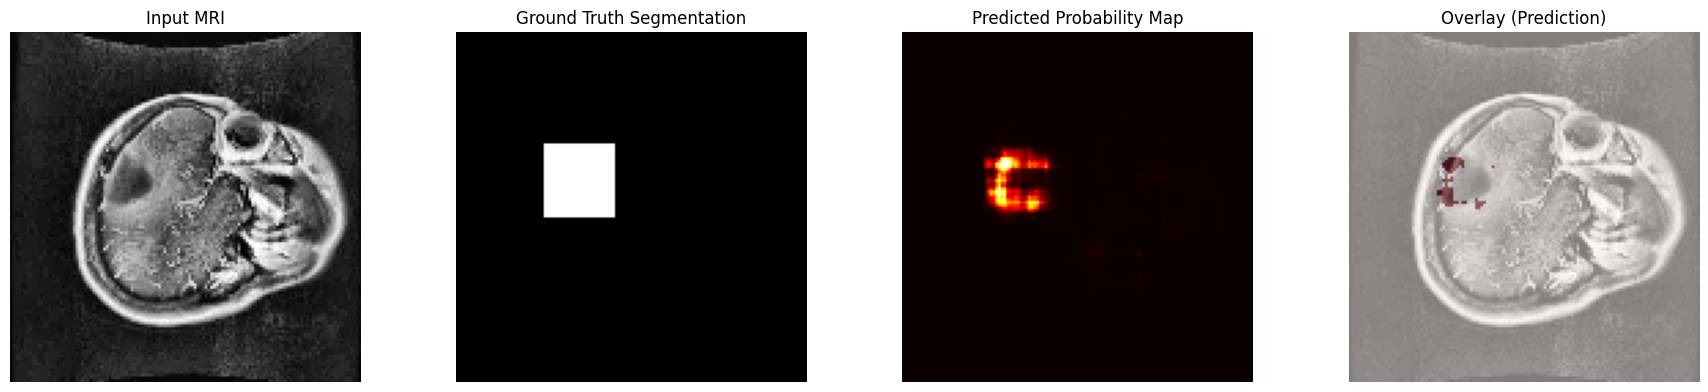

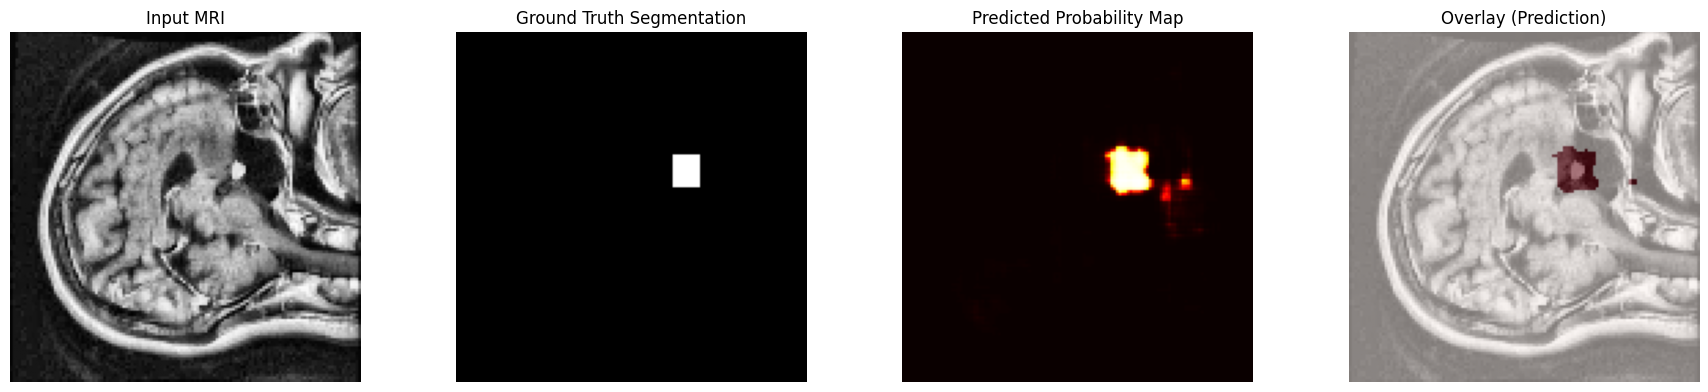

In [109]:
visualize_segmentation(model, test_ds, idx=3, device=device)
visualize_segmentation(model, test_ds, idx=15, device=device)
visualize_segmentation(model, test_ds, idx=40, device=device)